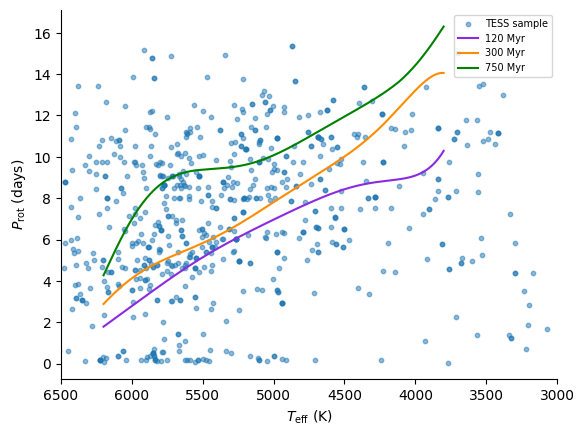

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df_temp = pd.read_csv("ASTR502_Mega_Target_List.csv")
df_prot = pd.read_csv("FINAL_TRUE_TESS_Rotation_Period_Sample.csv")

# Clean TIC IDs
df_temp["tic_id"] = pd.to_numeric(
    df_temp["tic_id"].str.replace("TIC ", ""),
    errors="coerce"
)
df_prot["ticid"] = pd.to_numeric(df_prot["ticid"], errors="coerce")

df_temp = df_temp.dropna(subset=["tic_id"])
df_prot = df_prot.dropna(subset=["ticid"])

# One period per TIC
df_period_unique = df_prot.groupby("ticid")["periods"].median().reset_index()
df_period_unique = df_period_unique.rename(columns={"ticid": "tic_id"})

# Merge
df_merged = pd.merge(df_temp, df_period_unique, on="tic_id", how="inner")
df_merged = df_merged.dropna(subset=["st_teff", "periods"])

# Gyro Model
from gyrointerp.models import slow_sequence

teff_grid = np.linspace(3800, 6200, 1000)

gyro_120 = slow_sequence(teff_grid, 120)
gyro_300 = slow_sequence(teff_grid, 300)
gyro_750 = slow_sequence(teff_grid, 750)

#Plot everything together
plt.figure()

# data
plt.scatter(df_merged["st_teff"], df_merged["periods"], s=10, alpha=0.5, label="TESS sample")

# gyro curves
plt.plot(teff_grid, gyro_120, color = "blueviolet", label="120 Myr")
plt.plot(teff_grid, gyro_300, color = "darkorange", label="300 Myr")
plt.plot(teff_grid, gyro_750, color = "green", label="750 Myr")

plt.xlabel(r"$T_{\mathrm{eff}}$ (K)")
plt.ylabel(r"$P_{\mathrm{rot}}$ (days)")
#plt.title(r"$P_{\mathrm{rot}}$ vs $T_{\mathrm{eff}}$")

plt.gca().invert_xaxis()
plt.xlim(6500,3000)

# remove top/right spines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#plt.yscale("log")

plt.legend(loc="upper right", fontsize=7, frameon=True)
plt.show()


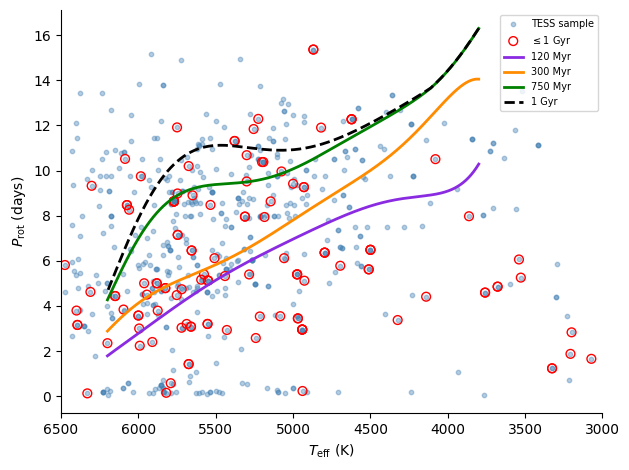

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── 1. Load data ────────────────────────────────────────────────
df_temp = pd.read_csv("ASTR502_Mega_Target_List.csv")
df_prot = pd.read_csv("FINAL_TRUE_TESS_Rotation_Period_Sample.csv")

# ── 2. Clean TIC IDs ────────────────────────────────────────────
df_temp["tic_id"] = pd.to_numeric(
    df_temp["tic_id"].str.replace("TIC ", ""),
    errors="coerce"
)

df_prot["ticid"] = pd.to_numeric(df_prot["ticid"], errors="coerce")

df_temp = df_temp.dropna(subset=["tic_id"])
df_prot = df_prot.dropna(subset=["ticid"])

# ── 3. One period per TIC (median across sectors) ───────────────
df_period_unique = df_prot.groupby("ticid")["periods"].median().reset_index()
df_period_unique = df_period_unique.rename(columns={"ticid": "tic_id"})

# ── 4. Merge (keep temperature + age) ───────────────────────────
df_merged = pd.merge(
    df_temp[["tic_id", "st_teff", "st_age"]],
    df_period_unique,
    on="tic_id",
    how="inner"
)

# Clean values
df_merged["st_age"] = pd.to_numeric(df_merged["st_age"], errors="coerce")
df_merged = df_merged.dropna(subset=["st_teff", "periods", "st_age"])

# ── 5. Select young stars (≤ 1 Gyr) ─────────────────────────────
young = df_merged[df_merged["st_age"] <= 1.0]

# ── 6. Gyrochronology models ───────────────────────────────────
from gyrointerp.models import slow_sequence

teff_grid = np.linspace(3800, 6200, 1000)

gyro_120  = slow_sequence(teff_grid, 120)
gyro_300  = slow_sequence(teff_grid, 300)
gyro_750  = slow_sequence(teff_grid, 750)
gyro_1000 = slow_sequence(teff_grid, 1000)

# ── 7. Plot ─────────────────────────────────────────────────────
plt.figure()

# All stars
plt.scatter(
    df_merged["st_teff"],
    df_merged["periods"],
    s=10,
    alpha=0.4,
    color="steelblue",
    label="TESS sample"
)

# Highlight young stars
plt.scatter(
    young["st_teff"],
    young["periods"],
    s=40,
    facecolors="none",
    edgecolors="red",
    linewidths=1,
    label=r"$\leq 1$ Gyr"
)

# Gyro curves
plt.plot(teff_grid, gyro_120,  color="blueviolet", lw=2, label="120 Myr")
plt.plot(teff_grid, gyro_300,  color="darkorange", lw=2, label="300 Myr")
plt.plot(teff_grid, gyro_750,  color="green", lw=2, label="750 Myr")
plt.plot(teff_grid, gyro_1000, color="black", lw=2, linestyle="--", label="1 Gyr")

# Labels
plt.xlabel(r"$T_{\mathrm{eff}}$ (K)")
plt.ylabel(r"$P_{\mathrm{rot}}$ (days)")

# Axes formatting
plt.gca().invert_xaxis()
plt.xlim(6500, 3000)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
plt.legend(loc="upper right", fontsize=7, frameon=True)

plt.tight_layout()
plt.show()